<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 138.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 162.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 145.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 140.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 145.7 MB/s eta 0:00:00


#### Step 1: Load the dataset


In [9]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

df.head(3)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




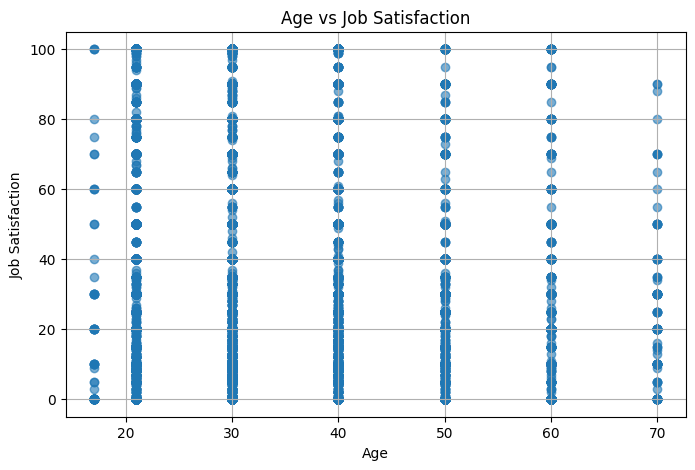

In [11]:
## Write your code here

# Query data

# Map Age to numeric
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['AgeNumeric'] = df['Age'].map(age_mapping)

# Convert Job Satisfaction
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop missing
df = df.dropna(subset=['AgeNumeric', 'JobSatPoints_6'])

# Plot
plt.figure(figsize=(8,5))
plt.scatter(df['AgeNumeric'], df['JobSatPoints_6'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Job Satisfaction')
plt.title('Age vs Job Satisfaction')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


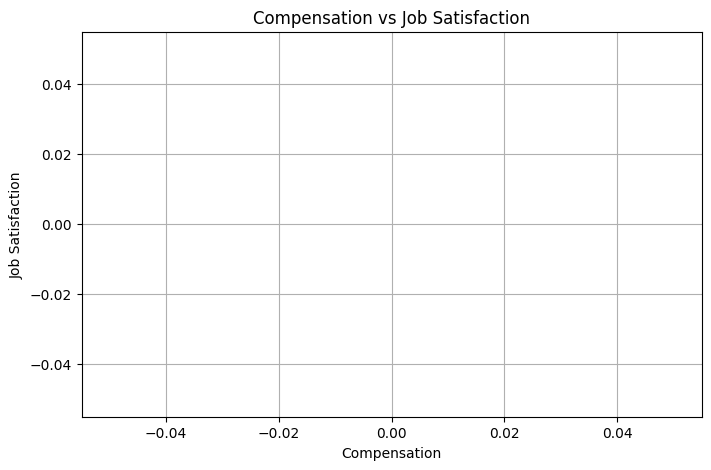

In [8]:
## Write your code here

# Query data

df2 = df

# Convert to numeric
df2['ConvertedCompYearly'] = pd.to_numeric(df2['ConvertedCompYearly'], errors='coerce')
df2['JobSatPoints_6'] = pd.to_numeric(df2['JobSatPoints_6'], errors='coerce')

# Drop missing
df2 = df2.dropna()

# Plot
plt.figure(figsize=(8,5))
plt.scatter(df2['ConvertedCompYearly'], df2['JobSatPoints_6'], alpha=0.6)
plt.xlabel('Compensation')
plt.ylabel('Job Satisfaction')
plt.title('Compensation vs Job Satisfaction')
plt.grid(True)
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


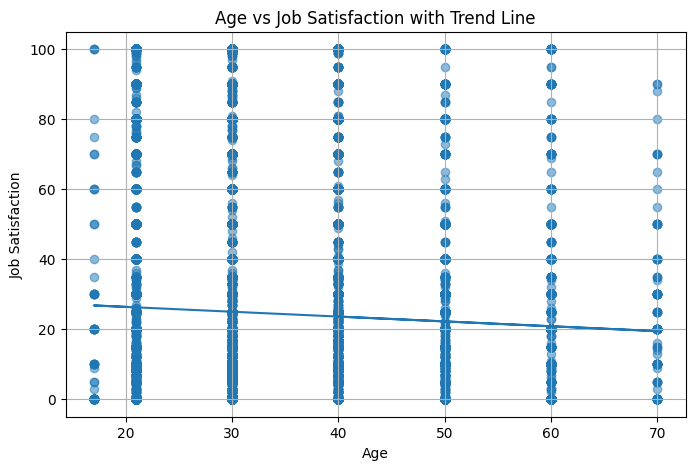

In [19]:
## Write your code here
import numpy as np
# Reuse df from first query or query again

# Map Age
df['AgeNumeric'] = df['Age'].map(age_mapping)

# Convert JobSat
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop missing
df = df.dropna(subset=['AgeNumeric', 'JobSatPoints_6'])

# Scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['AgeNumeric'], df['JobSatPoints_6'], alpha=0.5)

# Add regression line
z = np.polyfit(df['AgeNumeric'], df['JobSatPoints_6'], 1)
p = np.poly1d(z)

plt.plot(df['AgeNumeric'], p(df['AgeNumeric']))

plt.xlabel('Age')
plt.ylabel('Job Satisfaction')
plt.title('Age vs Job Satisfaction with Trend Line')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


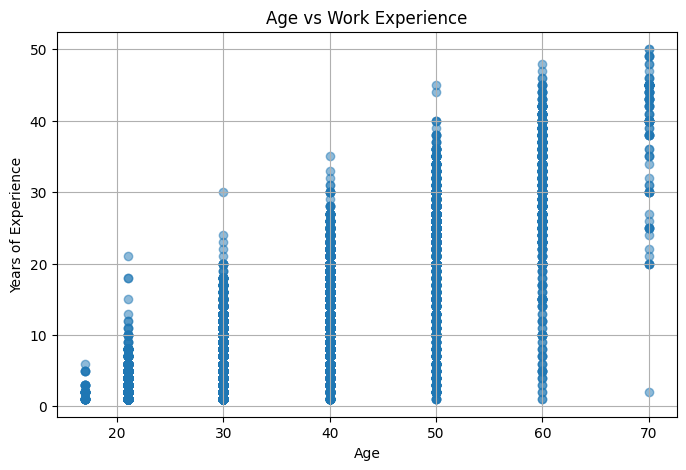

In [20]:
## Write your code here


df['AgeNumeric'] = df['Age'].map(age_mapping)

# Convert YearsCodePro
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Drop missing
df_age_exp = df.dropna(subset=['AgeNumeric', 'YearsCodePro'])

# Plot
plt.figure(figsize=(8,5))
plt.scatter(df_age_exp['AgeNumeric'], df_age_exp['YearsCodePro'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Years of Experience')
plt.title('Age vs Work Experience')
plt.grid(True)
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


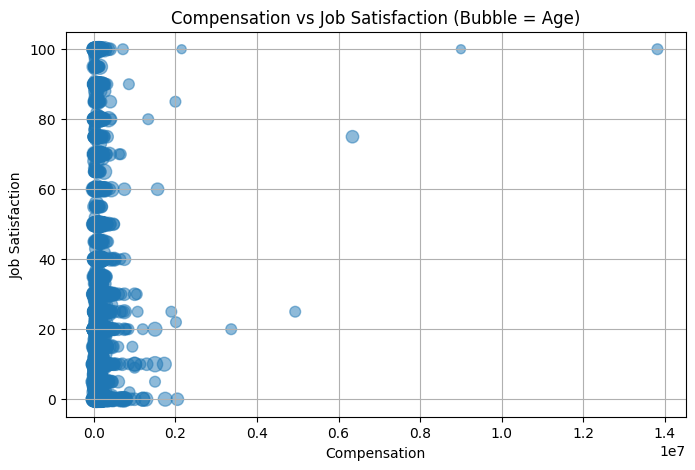

In [21]:
## Write your code here

# Convert columns
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop missing
df_bubble = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'AgeNumeric'])

# Plot
plt.figure(figsize=(8,5))
plt.scatter(
    df_bubble['ConvertedCompYearly'],
    df_bubble['JobSatPoints_6'],
    s=df_bubble['AgeNumeric']*2,  # bubble size
    alpha=0.5
)

plt.xlabel('Compensation')
plt.ylabel('Job Satisfaction')
plt.title('Compensation vs Job Satisfaction (Bubble = Age)')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


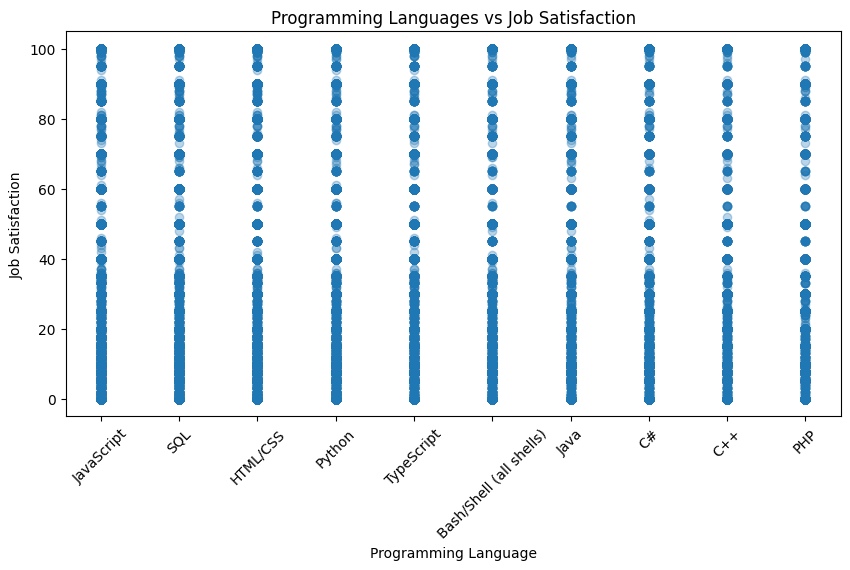

In [22]:
## Write your code here

# Keep needed columns
df_lang = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].copy()

# Convert JobSat
df_lang['JobSatPoints_6'] = pd.to_numeric(df_lang['JobSatPoints_6'], errors='coerce')

# Drop missing
df_lang = df_lang.dropna()

# Split languages
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.split(';')

# Explode (one language per row)
df_lang = df_lang.explode('LanguageHaveWorkedWith')

# Take top 10 languages
top_langs = df_lang['LanguageHaveWorkedWith'].value_counts().nlargest(10).index
df_lang = df_lang[df_lang['LanguageHaveWorkedWith'].isin(top_langs)]

# Encode languages as numbers
lang_codes = {lang: i for i, lang in enumerate(top_langs)}
df_lang['LangCode'] = df_lang['LanguageHaveWorkedWith'].map(lang_codes)

# Plot
plt.figure(figsize=(10,5))
plt.scatter(df_lang['LangCode'], df_lang['JobSatPoints_6'], alpha=0.3)

plt.xticks(range(len(top_langs)), top_langs, rotation=45)
plt.xlabel('Programming Language')
plt.ylabel('Job Satisfaction')
plt.title('Programming Languages vs Job Satisfaction')
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


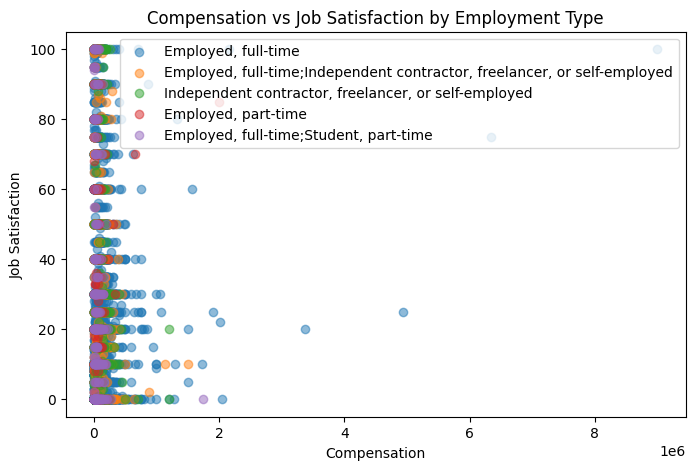

In [23]:
## Write your code here

# Prepare data
df_emp = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].copy()

df_emp['ConvertedCompYearly'] = pd.to_numeric(df_emp['ConvertedCompYearly'], errors='coerce')
df_emp['JobSatPoints_6'] = pd.to_numeric(df_emp['JobSatPoints_6'], errors='coerce')

df_emp = df_emp.dropna()

# Get top employment types (to avoid clutter)
top_emp = df_emp['Employment'].value_counts().nlargest(5).index
df_emp = df_emp[df_emp['Employment'].isin(top_emp)]

# Plot
plt.figure(figsize=(8,5))

for emp in top_emp:
    subset = df_emp[df_emp['Employment'] == emp]
    plt.scatter(subset['ConvertedCompYearly'], subset['JobSatPoints_6'], alpha=0.5, label=emp)

plt.xlabel('Compensation')
plt.ylabel('Job Satisfaction')
plt.title('Compensation vs Job Satisfaction by Employment Type')
plt.legend()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


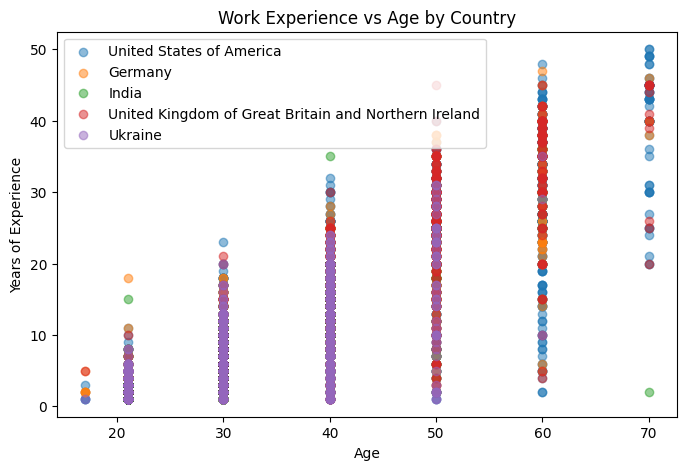

In [24]:
## Write your code here

# Prepare data
df_country = df[['YearsCodePro', 'AgeNumeric', 'Country']].copy()

df_country['YearsCodePro'] = pd.to_numeric(df_country['YearsCodePro'], errors='coerce')
df_country = df_country.dropna()

# Top 5 countries
top_countries = df_country['Country'].value_counts().nlargest(5).index
df_country = df_country[df_country['Country'].isin(top_countries)]

# Plot
plt.figure(figsize=(8,5))

for country in top_countries:
    subset = df_country[df_country['Country'] == country]
    plt.scatter(subset['AgeNumeric'], subset['YearsCodePro'], alpha=0.5, label=country)

plt.xlabel('Age')
plt.ylabel('Years of Experience')
plt.title('Work Experience vs Age by Country')
plt.legend()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
